# Embedding Extraction and Model Training

**Purpose**: Extract frozen ESM-2 (protein) and ChemBERTa (ligand)
embeddings for the Davis mini dataset, train a fusion MLP regression head,
and evaluate binding affinity prediction performance.

**Input**: `davis_mini.csv` (4,237 drug–target pairs, 68 unique drugs,
379 unique proteins, see `01_eda_and_preprocessing.ipynb` for how this
was built)

In [10]:
!pip install -q transformers torch pandas numpy scikit-learn matplotlib

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import pandas as pd
import torch

print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

# load the mini dataset saved from notebook 01
mini_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/davis_mini.csv')
print(f"\nLoaded {len(mini_df)} rows")
mini_df.head()

CUDA available: True
Device: Tesla T4

Loaded 4237 rows


,Drug_ID,Drug,Target_ID,Target,Y
0,11712649,O=C(O)c1ccc(Nc2ncc3c(n2)-c2ccc(Cl)cc2C(c2c(F)c...,FES,MGFSSELCSPQGHGVLQQMQEAELRLLEGMRKWMAQRVKSDREYAG...,4.999996
1,6450551,CNC(=O)c1ccccc1Sc1ccc2c(C=Cc3ccccn3)n[nH]c2c1,TRKA,MLRGGRRGQLGWHSWAAGPGSLLAWLILASAGAAPCPDACCPHGSS...,5.744703
2,10138260,Cc1[nH]c(C=C2C(=O)Nc3ccc(F)cc32)c(C)c1C(=O)NCC...,PRKCI,MPTQRDSSTMSHTVAGGGSGDHSHQVRVKAYYRGDIMITHFEPSIS...,4.999996
3,156422,Cc1ccc(-n2nc(C(C)(C)C)cc2NC(=O)Nc2ccc(OCCN3CCO...,LKB1,MEVVDPQQLGMFTEGELMSVGMDTFIHRIDSTEVIYQPRRKRAKLI...,4.999996
4,16038120,COc1cc(N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc(Cl)c(N...,RIOK1,MDYRRLLMSRVVPGQFDDADSSDSENRDLKTVKEKDDILFEDLQDN...,4.999996


In [13]:
# load ESM-2 protein encoder, frozen
# using the smallest ESM-2 checkpoint (8M params, embedding dim 320)
# no fine tuning, only used as a feature extractor

from transformers import AutoTokenizer, AutoModel
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

esm_model_name = "facebook/esm2_t6_8M_UR50D"
esm_tokenizer = AutoTokenizer.from_pretrained(esm_model_name)
esm_model = AutoModel.from_pretrained(esm_model_name).to(device)
esm_model.eval()  # inference mode, no dropout/gradients

# freeze all parameters
for param in esm_model.parameters():
    param.requires_grad = False

print("ESM-2 loaded:", esm_model_name)
print("Embedding dimension:", esm_model.config.hidden_size)

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ESM-2 loaded: facebook/esm2_t6_8M_UR50D
Embedding dimension: 320


In [15]:
# extract ESM-2 embeddings for all unique proteins

unique_proteins = mini_df[['Target_ID', 'Target']].drop_duplicates()
print(f"{len(unique_proteins)} unique proteins")

protein_embeddings = {}

with torch.no_grad():
    for i, row in unique_proteins.iterrows():
        seq = row['Target']
        target_id = row['Target_ID']

        # tokenize the protein sequence
        inputs = esm_tokenizer(seq, return_tensors="pt", truncation=False).to(device)

        # forward pass through frozen ESM-2
        outputs = esm_model(**inputs)

        # mean pooling over the sequence length dimension
        # (outputs.last_hidden_state shape: [1, seq_len, 320])
        embedding = outputs.last_hidden_state.mean(dim=1).squeeze(0).cpu()

        protein_embeddings[target_id] = embedding

        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{len(unique_proteins)} done")

print("Done. Total embeddings:", len(protein_embeddings))
print("Embedding shape example:", list(protein_embeddings.values())[0].shape)


379 unique proteins
  50/379 done
  100/379 done
  150/379 done
  200/379 done
  350/379 done
  400/379 done
Done. Total embeddings: 379
Embedding shape example: torch.Size([320])


In [16]:
# load ChemBERTa, frozen

chemberta_model_name = "seyonec/ChemBERTa-zinc-base-v1"
chem_tokenizer = AutoTokenizer.from_pretrained(chemberta_model_name)
chem_model = AutoModel.from_pretrained(chemberta_model_name).to(device)
chem_model.eval()

for param in chem_model.parameters():
    param.requires_grad = False

print("ChemBERTa loaded:", chemberta_model_name)
print("Embedding dimension:", chem_model.config.hidden_size)

config.json:   0%|          | 0.00/501 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/9.43k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.21k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  179MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ChemBERTa loaded: seyonec/ChemBERTa-zinc-base-v1
Embedding dimension: 768


In [17]:
# extract ChemBERTa embeddings for all unique drugs

unique_drugs = mini_df[['Drug_ID', 'Drug']].drop_duplicates()
print(f"{len(unique_drugs)} unique proteins")

drug_embeddings = {}

with torch.no_grad():
    for i, row in unique_drugs.iterrows():
        smiles = row['Drug']
        drug_id = row['Drug_ID']

        inputs = chem_tokenizer(smiles, return_tensors="pt", truncation=True, max_length=128).to(device)
        outputs = chem_model(**inputs)

        # mean pooling over token dimension
        embedding = outputs.last_hidden_state.mean(dim=1).squeeze(0).cpu()

        drug_embeddings[drug_id] = embedding

        if (i + 1) % 10 == 0:
            print(f"  {i+1}/{len(unique_drugs)} done")

print("Done. Total embeddings:", len(drug_embeddings))
print("Embedding shape example:", list(drug_embeddings.values())[0].shape)


68 unique proteins
  10/68 done
  20/68 done
  30/68 done
  40/68 done
  60/68 done
  100/68 done
  150/68 done
  240/68 done
Done. Total embeddings: 68
Embedding shape example: torch.Size([768])


## Embedding Extraction Summary

- **Protein embeddings**: 379/379 unique proteins, ESM-2 (esm2_t6_8M), 320-dim, frozen
- **Drug embeddings**: 68/68 unique drugs, ChemBERTa (zinc-base-v1), 768-dim, frozen
- **Fusion input dimension**: 320 + 768 = 1088

In [18]:
# assemble the full feature matrix
# for each of the 4237 drug-target pairs,
# look up the corresponding protein + drug embedding and concatenate them into one feature vector

import numpy as np

X = []
y = []

for _, row in mini_df.iterrows():
    protein_emb = protein_embeddings[row['Target_ID']]
    drug_emb = drug_embeddings[row['Drug_ID']]

    # concatenate protein + drug embeddings into one vector
    combined = torch.cat([protein_emb, drug_emb], dim=0)

    X.append(combined.numpy())
    y.append(row['Y'])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)  # should be (4237, 1088)
print("y shape:", y.shape)  # should be (4237,)

X shape: (4237, 1088)
y shape: (4237,)


In [19]:
# train, validation, test split (random split)
# using a standard random 70/15/15 split for this first pass

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (2965, 1088) Val: (636, 1088) Test: (636, 1088)


In [20]:
# standardize features

# fit the scaler only on training data, then apply it to val/test,
# prevents information from val/test leaking into the preprocessing step

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Mean of scaled train (should be ~0):", X_train_scaled.mean())
print("Std of scaled train (should be ~1):", X_train_scaled.std())

Mean of scaled train (should be ~0): 1.8949796e-10
Std of scaled train (should be ~1): 1.0000001


In [21]:
# define the fusion MLP regression head
# architecture: 1088 (concatenated embedding) -> 256 -> 64 -> 1

import torch.nn as nn

class FusionMLP(nn.Module):
    def __init__(self, input_dim=1088):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

model = FusionMLP(input_dim=X_train_scaled.shape[1]).to(device)
print(model)

FusionMLP(
  (net): Sequential(
    (0): Linear(in_features=1088, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [25]:
# training loop with mini-batches

from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Re-initialize the model fresh (previous training run is discarded)
model = FusionMLP(input_dim=X_train_scaled.shape[1]).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=5e-4)  # lowered from 1e-3

n_epochs = 100
patience = 8  # increased, since mini-batch loss is noisier epoch-to-epoch
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

for epoch in range(n_epochs):
    model.train()
    epoch_train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * xb.size(0)
    epoch_train_loss /= len(train_dataset)

    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t)
        val_loss = criterion(val_preds, y_val_t)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}: train_loss={epoch_train_loss:.4f}, val_loss={val_loss.item():.4f}")

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_model_state)
print("\nTraining complete. Best val loss:", best_val_loss)

Epoch 1: train_loss=15.3083, val_loss=1.8194
Epoch 5: train_loss=1.0250, val_loss=0.9322
Epoch 10: train_loss=0.8472, val_loss=0.8817
Epoch 15: train_loss=0.7834, val_loss=0.8664
Early stopping at epoch 19

Training complete. Best val loss: 0.8502004146575928


In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    test_preds = model(X_test_t).cpu().numpy()

rmse = np.sqrt(mean_squared_error(y_test, test_preds))
mae = mean_absolute_error(y_test, test_preds)
r2 = r2_score(y_test, test_preds)
pearson_corr, _ = pearsonr(y_test, test_preds)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE:  {mae:.4f}")
print(f"Test R²:   {r2:.4f}")
print(f"Pearson r: {pearson_corr:.4f}")

Test RMSE: 0.9743
Test MAE:  0.7529
Test R²:   0.3739
Pearson r: 0.6180


In [29]:
!pip install -q rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 21.3 MB/s eta 0:00:00


In [30]:
# Baseline model - Morgan Fingerprint (drug) + simple protein descriptor + XGBoost

from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

def get_morgan_fingerprint(smiles, n_bits=1024, radius=2):
    mol = Chem.MolFromSmiles(smiles)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    return np.array(fp)

# Precompute Morgan fingerprints for unique drugs (same "unique-only" trick as before)
morgan_fps = {}
for _, row in unique_drugs.iterrows():
    morgan_fps[row['Drug_ID']] = get_morgan_fingerprint(row['Drug'])

print("Morgan fingerprint shape example:", list(morgan_fps.values())[0].shape)

[03:44:09] DEPRECATION WARNING: please use MorganGenerator
[03:44:09] DEPRECATION WARNING: please use MorganGenerator
[03:44:09] DEPRECATION WARNING: please use MorganGenerator
[03:44:09] DEPRECATION WARNING: please use MorganGenerator
[03:44:09] DEPRECATION WARNING: please use MorganGenerator
[03:44:09] DEPRECATION WARNING: please use MorganGenerator
[03:44:09] DEPRECATION WARNING: please use MorganGenerator
[03:44:09] DEPRECATION WARNING: please use MorganGenerator
[03:44:09] DEPRECATION WARNING: please use MorganGenerator
[03:44:09] DEPRECATION WARNING: please use MorganGenerator
[03:44:09] DEPRECATION WARNING: please use MorganGenerator
[03:44:09] DEPRECATION WARNING: please use MorganGenerator
[03:44:09] DEPRECATION WARNING: please use MorganGenerator
[03:44:09] DEPRECATION WARNING: please use MorganGenerator
[03:44:09] DEPRECATION WARNING: please use MorganGenerator
[03:44:09] DEPRECATION WARNING: please use MorganGenerator
[03:44:09] DEPRECATION WARNING: please use MorganGenerat

Morgan fingerprint shape example: (1024,)


[03:44:09] DEPRECATION WARNING: please use MorganGenerator
[03:44:09] DEPRECATION WARNING: please use MorganGenerator


In [31]:
# assemble baseline feature matrix
# Protein side: same ESM-2 embeddings (kept constant across both models)
# Drug side: Morgan fingerprint (1024-dim) instead of ChemBERTa

X_baseline = []

for _, row in mini_df.iterrows():
    protein_emb = protein_embeddings[row['Target_ID']].numpy()
    drug_fp = morgan_fps[row['Drug_ID']]

    combined = np.concatenate([protein_emb, drug_fp])
    X_baseline.append(combined)

X_baseline = np.array(X_baseline)
print("X_baseline shape:", X_baseline.shape)  # should be (4237, 320+1024=1344)

X_baseline shape: (4237, 1344)


In [32]:
# split baseline features using the same indices as the Transformer model

indices = np.arange(len(mini_df))
idx_train, idx_temp = train_test_split(indices, test_size=0.3, random_state=42)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.5, random_state=42)

X_baseline_train = X_baseline[idx_train]
X_baseline_val = X_baseline[idx_val]
X_baseline_test = X_baseline[idx_test]

y_baseline_train = y[idx_train]
y_baseline_val = y[idx_val]
y_baseline_test = y[idx_test]

# Sanity check: y_baseline_train should exactly match y_train from before
print("Match check (should be True):", np.allclose(y_baseline_train, y_train))
print("Baseline train/val/test shapes:", X_baseline_train.shape, X_baseline_val.shape, X_baseline_test.shape)

Match check (should be True): True
Baseline train/val/test shapes: (2965, 1344) (636, 1344) (636, 1344)


In [33]:
# train XGBoost baseline

!pip install -q xgboost

import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=20,
    eval_metric='rmse'
)

xgb_model.fit(
    X_baseline_train, y_baseline_train,
    eval_set=[(X_baseline_val, y_baseline_val)],
    verbose=20
)

print("\nBest iteration:", xgb_model.best_iteration)

[0]	validation_0-rmse:1.18437
[20]	validation_0-rmse:0.99589
[40]	validation_0-rmse:0.93437
[60]	validation_0-rmse:0.90575
[80]	validation_0-rmse:0.88712
[100]	validation_0-rmse:0.87898
[120]	validation_0-rmse:0.87533
[140]	validation_0-rmse:0.86756
[160]	validation_0-rmse:0.86218
[180]	validation_0-rmse:0.85925
[200]	validation_0-rmse:0.85675
[220]	validation_0-rmse:0.85519
[240]	validation_0-rmse:0.85257
[260]	validation_0-rmse:0.85076
[280]	validation_0-rmse:0.84670
[299]	validation_0-rmse:0.84359

Best iteration: 293


In [34]:
# evaluate XGBoost baseline on test set

xgb_test_preds = xgb_model.predict(X_baseline_test)

xgb_rmse = np.sqrt(mean_squared_error(y_baseline_test, xgb_test_preds))
xgb_mae = mean_absolute_error(y_baseline_test, xgb_test_preds)
xgb_r2 = r2_score(y_baseline_test, xgb_test_preds)
xgb_pearson, _ = pearsonr(y_baseline_test, xgb_test_preds)

print(f"Baseline (Morgan FP + XGBoost) Test Metrics:")
print(f"  RMSE: {xgb_rmse:.4f}")
print(f"  MAE:  {xgb_mae:.4f}")
print(f"  R²:   {xgb_r2:.4f}")
print(f"  Pearson r: {xgb_pearson:.4f}")

print(f"\n--- Comparison ---")
print(f"{'Metric':<12}{'Baseline (Morgan+XGB)':<25}{'Transformer (ESM2+ChemBERTa)'}")
print(f"{'RMSE':<12}{xgb_rmse:<25.4f}{rmse:.4f}")
print(f"{'MAE':<12}{xgb_mae:<25.4f}{mae:.4f}")
print(f"{'R²':<12}{xgb_r2:<25.4f}{r2:.4f}")
print(f"{'Pearson r':<12}{xgb_pearson:<25.4f}{pearson_corr:.4f}")

Baseline (Morgan FP + XGBoost) Test Metrics:
  RMSE: 0.8943
  MAE:  0.7010
  R²:   0.4725
  Pearson r: 0.6912

--- Comparison ---
Metric      Baseline (Morgan+XGB)    Transformer (ESM2+ChemBERTa)
RMSE        0.8943                   0.9743
MAE         0.7010                   0.7529
R²          0.4725                   0.3739
Pearson r   0.6912                   0.6180


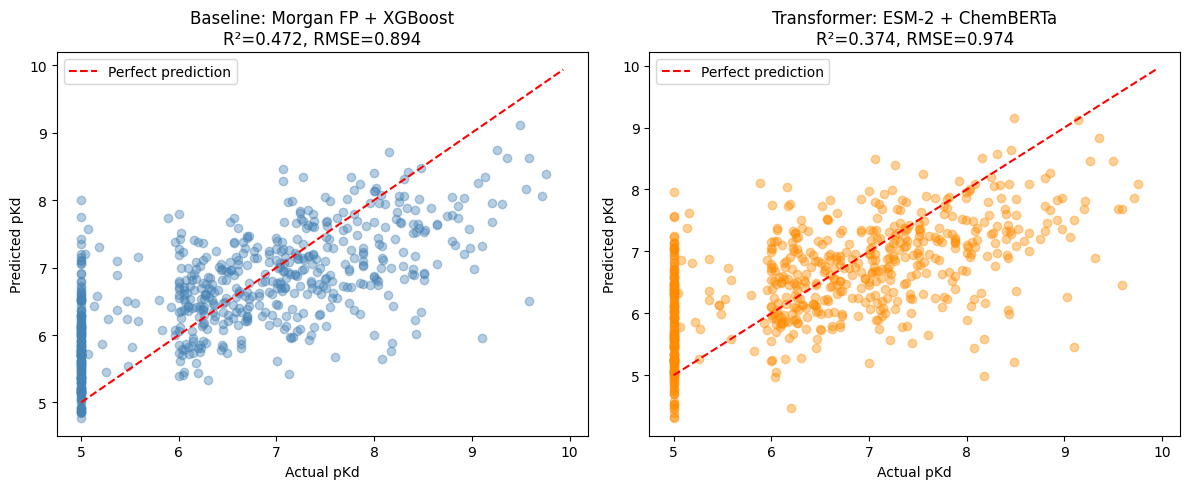

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Baseline (Morgan FP + XGBoost)
axes[0].scatter(y_baseline_test, xgb_test_preds, alpha=0.4, color='steelblue')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual pKd')
axes[0].set_ylabel('Predicted pKd')
axes[0].set_title(f'Baseline: Morgan FP + XGBoost\nR²={xgb_r2:.3f}, RMSE={xgb_rmse:.3f}')
axes[0].legend()

# Transformer (ESM-2 + ChemBERTa)
axes[1].scatter(y_test, test_preds, alpha=0.4, color='darkorange')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect prediction')
axes[1].set_xlabel('Actual pKd')
axes[1].set_ylabel('Predicted pKd')
axes[1].set_title(f'Transformer: ESM-2 + ChemBERTa\nR²={r2:.3f}, RMSE={rmse:.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('predicted_vs_actual_comparison.png', dpi=150)
plt.show()

In [36]:
# retry MLP with adjusted hyperparameters

class FusionMLP_v2(nn.Module):
    def __init__(self, input_dim=1088):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

model_v2 = FusionMLP_v2(input_dim=X_train_scaled.shape[1]).to(device)
optimizer_v2 = optim.Adam(model_v2.parameters(), lr=5e-4)

n_epochs = 150
patience = 15
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

for epoch in range(n_epochs):
    model_v2.train()
    epoch_train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_v2.zero_grad()
        preds = model_v2(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer_v2.step()
        epoch_train_loss += loss.item() * xb.size(0)
    epoch_train_loss /= len(train_dataset)

    model_v2.eval()
    with torch.no_grad():
        val_preds = model_v2(X_val_t)
        val_loss = criterion(val_preds, y_val_t)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}: train_loss={epoch_train_loss:.4f}, val_loss={val_loss.item():.4f}")

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        patience_counter = 0
        best_model_state = model_v2.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model_v2.load_state_dict(best_model_state)
print("\nBest val loss:", best_val_loss)

Epoch 1: train_loss=8.9472, val_loss=1.3494
Epoch 10: train_loss=0.7987, val_loss=0.9594
Epoch 20: train_loss=0.5929, val_loss=0.9000
Epoch 30: train_loss=0.4919, val_loss=0.8689
Epoch 40: train_loss=0.4028, val_loss=0.8254
Early stopping at epoch 48

Best val loss: 0.8091136813163757


In [37]:
# evaluate tuned MLP (v2) on test set

model_v2.eval()
with torch.no_grad():
    test_preds_v2 = model_v2(X_test_t).cpu().numpy()

rmse_v2 = np.sqrt(mean_squared_error(y_test, test_preds_v2))
mae_v2 = mean_absolute_error(y_test, test_preds_v2)
r2_v2 = r2_score(y_test, test_preds_v2)
pearson_v2, _ = pearsonr(y_test, test_preds_v2)

print(f"--- Full Comparison ---")
print(f"{'Metric':<12}{'Baseline (Morgan+XGB)':<25}{'Transformer v1':<18}{'Transformer v2 (tuned)'}")
print(f"{'RMSE':<12}{xgb_rmse:<25.4f}{rmse:<18.4f}{rmse_v2:.4f}")
print(f"{'MAE':<12}{xgb_mae:<25.4f}{mae:<18.4f}{mae_v2:.4f}")
print(f"{'R²':<12}{xgb_r2:<25.4f}{r2:<18.4f}{r2_v2:.4f}")
print(f"{'Pearson r':<12}{xgb_pearson:<25.4f}{pearson_corr:<18.4f}{pearson_v2:.4f}")

--- Full Comparison ---
Metric      Baseline (Morgan+XGB)    Transformer v1    Transformer v2 (tuned)
RMSE        0.8943                   0.9743            0.9264
MAE         0.7010                   0.7529            0.7198
R²          0.4725                   0.3739            0.4339
Pearson r   0.6912                   0.6180            0.6710


In [38]:
# Per-bin error analysis
# check whether the models perform differently across weak vs strong binding affinity ranges

# Define bins based on pKd ranges (roughly matching our earlier EDA bins)
bin_edges = [4.9, 5.5, 6.5, 7.5, 8.5, 10.0]
bin_labels = ['5.0-5.5 (weak)', '5.5-6.5', '6.5-7.5', '7.5-8.5', '8.5+ (strong)']

def per_bin_metrics(y_true, y_pred, bin_edges, bin_labels):
    results = []
    bins = pd.cut(y_true, bins=bin_edges, labels=bin_labels, include_lowest=True)
    for label in bin_labels:
        mask = (bins == label)
        n = mask.sum()
        if n == 0:
            results.append((label, n, np.nan, np.nan))
            continue
        rmse_bin = np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))
        mae_bin = mean_absolute_error(y_true[mask], y_pred[mask])
        results.append((label, n, rmse_bin, mae_bin))
    return pd.DataFrame(results, columns=['pKd range', 'n_samples', 'RMSE', 'MAE'])

print("=== Baseline (Morgan FP + XGBoost) — per-bin error ===")
baseline_bins = per_bin_metrics(y_baseline_test, xgb_test_preds, bin_edges, bin_labels)
print(baseline_bins.to_string(index=False))

print("\n=== Transformer v2 (tuned) — per-bin error ===")
transformer_bins = per_bin_metrics(y_test, test_preds_v2, bin_edges, bin_labels)
print(transformer_bins.to_string(index=False))

=== Baseline (Morgan FP + XGBoost) — per-bin error ===
     pKd range  n_samples     RMSE      MAE
5.0-5.5 (weak)        188 1.068526 0.872153
       5.5-6.5        135 0.625462 0.502443
       6.5-7.5        168 0.595629 0.478507
       7.5-8.5        109 0.990383 0.791663
 8.5+ (strong)         36 1.440393 1.316346

=== Transformer v2 (tuned) — per-bin error ===
     pKd range  n_samples     RMSE      MAE
5.0-5.5 (weak)        188 1.023680 0.808385
       5.5-6.5        135 0.780495 0.634836
       6.5-7.5        168 0.706222 0.545544
       7.5-8.5        109 0.964728 0.748632
 8.5+ (strong)         36 1.503431 1.302083


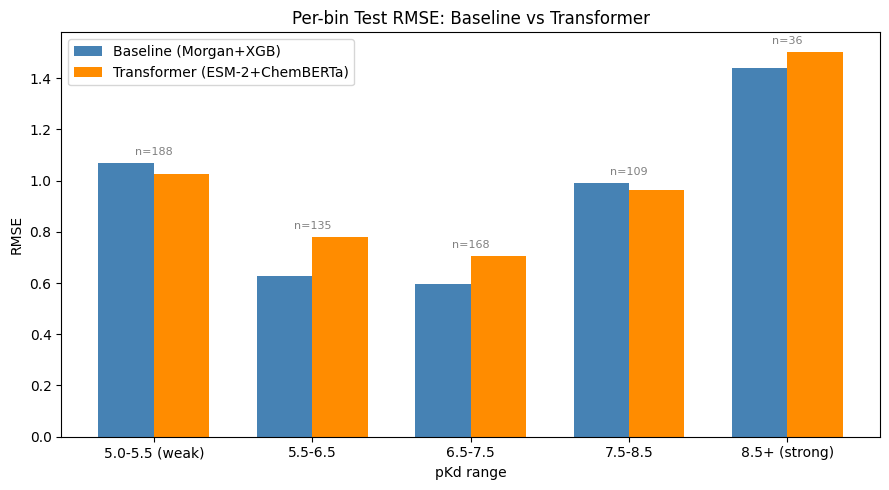

In [40]:
# visualize per-bin RMSE — Baseline vs Transformer

x = np.arange(len(bin_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, baseline_bins['RMSE'], width, label='Baseline (Morgan+XGB)', color='steelblue')
ax.bar(x + width/2, transformer_bins['RMSE'], width, label='Transformer (ESM-2+ChemBERTa)', color='darkorange')

ax.set_xlabel('pKd range')
ax.set_ylabel('RMSE')
ax.set_title('Per-bin Test RMSE: Baseline vs Transformer')
ax.set_xticks(x)
ax.set_xticklabels(bin_labels, rotation=0)
ax.legend()

for i, n in enumerate(baseline_bins['n_samples']):
    ax.text(i, max(baseline_bins['RMSE'][i], transformer_bins['RMSE'][i]) + 0.03,
             f'n={n}', ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

In [41]:
import pickle

# Convert tensors to numpy for portability
protein_emb_dict = {k: v.numpy() for k, v in protein_embeddings.items()}
drug_emb_dict = {k: v.numpy() for k, v in drug_embeddings.items()}

with open('protein_embeddings.pkl', 'wb') as f:
    pickle.dump(protein_emb_dict, f)

with open('drug_embeddings.pkl', 'wb') as f:
    pickle.dump(drug_emb_dict, f)

print("Saved protein_embeddings.pkl and drug_embeddings.pkl")

Saved protein_embeddings.pkl and drug_embeddings.pkl


In [42]:
import shutil
shutil.copy('protein_embeddings.pkl', '/content/drive/MyDrive/protein_embeddings.pkl')
shutil.copy('drug_embeddings.pkl', '/content/drive/MyDrive/drug_embeddings.pkl')
print("Copied to Drive")

Copied to Drive
